Goals of this project:

1. What is the overall on-time performance, and what do the overall distribution of adherence look like?

In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

# Sum the adjusted counts
total_late = df['ADJUSTED_LATE_COUNT'].sum()
total_early = df['ADJUSTED_EARLY_COUNT'].sum()
total_ontime = df['ADJUSTED_ONTIME_COUNT'].sum()

total = total_late + total_early + total_ontime

# Calculate percentages
late_pct = (total_late / total) * 100
early_pct = (total_early / total) * 100
ontime_pct = (total_ontime / total) * 100

print("On-Time Performance:")
print(f"On-Time: {ontime_pct:.2f}%")
print(f"Late: {late_pct:.2f}%")
print(f"Early: {early_pct:.2f}%")

On-Time Performance:
On-Time: 79.69%
Late: 17.42%
Early: 2.88%


How does direction of travel, route, or location affect the on-time performance?

In [2]:
direction_perf = df.groupby('ROUTE_DIRECTION_NAME').agg({
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_EARLY_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
})

direction_perf['TOTAL'] = direction_perf.sum(axis=1)

direction_perf['LATE_PCT'] = (direction_perf['ADJUSTED_LATE_COUNT'] / direction_perf['TOTAL']) * 100
direction_perf['EARLY_PCT'] = (direction_perf['ADJUSTED_EARLY_COUNT'] / direction_perf['TOTAL']) * 100
direction_perf['ONTIME_PCT'] = (direction_perf['ADJUSTED_ONTIME_COUNT'] / direction_perf['TOTAL']) * 100

direction_perf[['LATE_PCT', 'EARLY_PCT', 'ONTIME_PCT']]

,LATE_PCT,EARLY_PCT,ONTIME_PCT
ROUTE_DIRECTION_NAME,,,
FROM DOWNTOWN,22.085708,2.950822,74.963470
TO DOWNTOWN,12.182006,2.810316,85.007678


In [3]:
route_perf = df.groupby('ROUTE_ABBR').agg({
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_EARLY_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
})

route_perf['TOTAL'] = route_perf.sum(axis=1)

route_perf['ONTIME_PCT'] = (route_perf['ADJUSTED_ONTIME_COUNT'] / route_perf['TOTAL']) * 100

# Sort routes
route_perf_sorted = route_perf.sort_values('ONTIME_PCT')

print("Worst Routes:")
print(route_perf_sorted[['ONTIME_PCT']].head(3))

print("\nBest Routes:")
print(route_perf_sorted[['ONTIME_PCT']].tail(3))

Worst Routes:
            ONTIME_PCT
ROUTE_ABBR            
55           69.716198
3            75.879353
52           76.501713

Best Routes:
            ONTIME_PCT
ROUTE_ABBR            
50           85.174412
23           88.611202
22           89.296490


In [4]:
stop_perf = df.groupby('TIME_POINT_ABBR').agg({
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
})

stop_perf['TOTAL'] = stop_perf.sum(axis=1)

stop_perf['LATE_PCT'] = (stop_perf['ADJUSTED_LATE_COUNT'] / stop_perf['TOTAL']) * 100

# Worst locations
stop_perf.sort_values('LATE_PCT', ascending=False).head(10)

,ADJUSTED_LATE_COUNT,ADJUSTED_ONTIME_COUNT,TOTAL,LATE_PCT
TIME_POINT_ABBR,,,,
MCC5_7,31,2,33,93.939394
MCC5_11,49,21,70,70.000000
MCC5_12,23,16,39,58.974359
MCC4_20,43,55,98,43.877551
DCSCC,699,1021,1720,40.639535
MCC4_22,34,53,87,39.080460
MXDONEL,3338,6320,9658,34.562021
MXWHARF,3218,6578,9796,32.850143
SAMS,1509,3171,4680,32.243590


In [5]:
df.groupby('ROUTE_ABBR')['ADHERENCE'].mean().sort_values()

ROUTE_ABBR
55   -4.823302
52   -3.971342
3    -3.761491
7    -3.346555
56   -2.703988
50   -2.505022
23   -1.760110
22   -1.138107
Name: ADHERENCE, dtype: float64

The negative adherence shows they’re regularly behind schedule, not just occasionally. Some locations have really high lateness rates, close to always late, which means delays build up.

In [6]:
direction_perf = df.groupby('ROUTE_DIRECTION_NAME').agg({
    'ADJUSTED_LATE_COUNT': 'sum',
    'ADJUSTED_EARLY_COUNT': 'sum',
    'ADJUSTED_ONTIME_COUNT': 'sum'
})

direction_perf['TOTAL'] = direction_perf.sum(axis=1)

direction_perf['ONTIME_PCT'] = (
    direction_perf['ADJUSTED_ONTIME_COUNT'] / direction_perf['TOTAL']
) * 100

direction_perf[['ONTIME_PCT']]

,ONTIME_PCT
ROUTE_DIRECTION_NAME,
FROM DOWNTOWN,74.963470
TO DOWNTOWN,85.007678


These values show the total number of on-time departures in each direction. However, since they are raw counts, they do not indicate which direction performs better. To accurately compare performance, the percentage of on-time departures must be calculated for each direction.

Route 55 is only about 69.7% on time, while Route 22 reaches about 89.3%, showing a nearly 20% gap in reliability. Some stops also have high lateness rates, with certain locations exceeding 90% late, indicating consistent delay points. In contrast, direction of travel has little impact, as performance is similar in both directions. Overall, route and location are the main drivers of on-time performance.

3. How does time of day or day of week affect on-time performance?

In [7]:
df.columns

Index(['CALENDAR_ID', 'SERVICE_ABBR', 'ADHERENCE_ID', 'DATE', 'ROUTE_ABBR',
       'BLOCK_ABBR', 'OPERATOR', 'TRIP_ID', 'OVERLOAD_ID',
       'ROUTE_DIRECTION_NAME', 'TIME_POINT_ABBR', 'ROUTE_STOP_SEQUENCE',
       'TRIP_EDGE', 'LATITUDE', 'LONGITUDE', 'SCHEDULED_TIME',
       'ACTUAL_ARRIVAL_TIME', 'ACTUAL_DEPARTURE_TIME', 'ADHERENCE',
       'SCHEDULED_HDWY', 'ACTUAL_HDWY', 'HDWY_DEV', 'ADJUSTED_EARLY_COUNT',
       'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT', 'STOP_CANCELLED',
       'PREV_SCHED_STOP_CANCELLED', 'IS_RELIEF', 'DWELL_IN_MINS',
       'SCHEDULED_LAYOVER_MINUTES'],
      dtype='object')

In [8]:
import pandas as pd

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

# Convert date
df['DATE'] = pd.to_datetime(df['DATE'])

# Extract day of week
df['day_of_week'] = df['DATE'].dt.day_name()

In [9]:
# Convert arrival time to datetime
df['ACTUAL_ARRIVAL_TIME'] = pd.to_datetime(df['ACTUAL_ARRIVAL_TIME'], errors='coerce')

# Extract hour
df['hour'] = df['ACTUAL_ARRIVAL_TIME'].dt.hour

In [10]:
def time_block(hour):
    if pd.isna(hour):
        return None
    elif 6 <= hour < 9:
        return "Morning Peak"
    elif 9 <= hour < 15:
        return "Midday"
    elif 15 <= hour < 19:
        return "Evening Peak"
    else:
        return "Night"

df['time_block'] = df['hour'].apply(time_block)

In [11]:
time_perf = df.groupby('time_block')[['ADJUSTED_ONTIME_COUNT',
                                      'ADJUSTED_LATE_COUNT',
                                      'ADJUSTED_EARLY_COUNT']].sum()

time_perf['total'] = time_perf.sum(axis=1)
time_perf['on_time_pct'] = (time_perf['ADJUSTED_ONTIME_COUNT'] / time_perf['total']) * 100

print(time_perf['on_time_pct'].sort_values())

time_block
Evening Peak    71.018101
Night           80.808256
Morning Peak    82.656628
Midday          83.349313
Name: on_time_pct, dtype: float64


In [12]:
dow_perf = df.groupby('day_of_week')[['ADJUSTED_ONTIME_COUNT',
                                      'ADJUSTED_LATE_COUNT',
                                      'ADJUSTED_EARLY_COUNT']].sum()

dow_perf['total'] = dow_perf.sum(axis=1)
dow_perf['on_time_pct'] = (dow_perf['ADJUSTED_ONTIME_COUNT'] / dow_perf['total']) * 100

# Order days properly
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_perf = dow_perf.reindex(order)

print(dow_perf['on_time_pct'])

day_of_week
Monday       84.017171
Tuesday      80.145841
Wednesday    79.044976
Thursday     78.251906
Friday       75.067067
Saturday     79.282781
Sunday       85.259790
Name: on_time_pct, dtype: float64


In [13]:
print("Worst time of day:", time_perf['on_time_pct'].idxmin())
print("Best time of day:", time_perf['on_time_pct'].idxmax())

print("Worst day:", dow_perf['on_time_pct'].idxmin())
print("Best day:", dow_perf['on_time_pct'].idxmax())

Worst time of day: Evening Peak
Best time of day: Midday
Worst day: Friday
Best day: Sunday


4. How much of a factor does the driver have on on-time performance? The driver is indicated by the OPERATOR variable.

In [14]:
import pandas as pd

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

operator_perf = df.groupby('OPERATOR')[[
    'ADJUSTED_ONTIME_COUNT',
    'ADJUSTED_LATE_COUNT',
    'ADJUSTED_EARLY_COUNT'
]].sum()

operator_perf['total'] = operator_perf.sum(axis=1)
operator_perf['on_time_pct'] = (
    operator_perf['ADJUSTED_ONTIME_COUNT'] / operator_perf['total']
) * 100

operator_perf = operator_perf.sort_values('on_time_pct', ascending=False)

print(operator_perf['on_time_pct'])

OPERATOR
0       100.000000
56      100.000000
2294    100.000000
1762     98.328333
1706     97.727273
           ...    
2094     23.684211
1377     20.000000
2982      7.142857
473       0.000000
656       0.000000
Name: on_time_pct, Length: 341, dtype: float64


On-time performance varies by operator, some drivers are showing 100% and others are showing below 25%. This suggests that the operator can be a factor in on-time performance. However, the differences may also be influenced by other factors like route difficulty, traffic conditions, and time of day, so operator performance alone does not fully explain the variation.

5.Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

# Keep only needed columns
data = df[['ADHERENCE', 'HDWY_DEV', 'SCHEDULED_HDWY']].copy()

# Convert to numeric (important fix)
data['ADHERENCE'] = pd.to_numeric(data['ADHERENCE'], errors='coerce')
data['HDWY_DEV'] = pd.to_numeric(data['HDWY_DEV'], errors='coerce')
data['SCHEDULED_HDWY'] = pd.to_numeric(data['SCHEDULED_HDWY'], errors='coerce')

# Remove invalid rows
data = data.dropna()

# Remove zero scheduled headway (prevents division errors)
data = data[data['SCHEDULED_HDWY'] > 0]

# Create deviation percentage
data['hdwy_dev_pct'] = data['HDWY_DEV'] / data['SCHEDULED_HDWY']

# Remove infinite values if any remain
data = data.replace([np.inf, -np.inf], np.nan).dropna()

# Final correlation
correlation = data['ADHERENCE'].corr(data['hdwy_dev_pct'])

print("Correlation between Adherence and Headway Deviation %:")
print(correlation)

Correlation between Adherence and Headway Deviation %:
-0.2037260846837519


There is a very weak relationship between bus lateness and headway spacing. This means that when buses are more unevenly spaced, they are only slightly more likely to be late, but the connection is not strong enough to say one really causes the other.

Stretch Goals 

6. How much impact does being late or too spaced out at the first stop have downstream?

In [18]:
print(len(df))

350329


In [19]:
import pandas as pd

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

# Keep only needed columns early (VERY important for speed)
df = df[['ROUTE_STOP_SEQUENCE', 'ADHERENCE']]

# Convert once
df['ROUTE_STOP_SEQUENCE'] = pd.to_numeric(df['ROUTE_STOP_SEQUENCE'], errors='coerce')
df['ADHERENCE'] = pd.to_numeric(df['ADHERENCE'], errors='coerce')

# Drop bad rows
df = df.dropna()

# Pre-calculate thresholds ONCE
low = df['ROUTE_STOP_SEQUENCE'].quantile(0.33)
high = df['ROUTE_STOP_SEQUENCE'].quantile(0.66)

# Fast vectorized segmentation
df['segment'] = 'Final Third'
df.loc[df['ROUTE_STOP_SEQUENCE'] <= low, 'segment'] = 'First Third'
df.loc[(df['ROUTE_STOP_SEQUENCE'] > low) & (df['ROUTE_STOP_SEQUENCE'] <= high), 'segment'] = 'Middle Third'

# Results
result = df.groupby('segment')['ADHERENCE'].mean()

print(result)

segment
Final Third    -3.381749
First Third    -2.897206
Middle Third   -3.419813
Name: ADHERENCE, dtype: float64


The results show that the schedule is consistent throughout the route. Buses are slightly early at all stages. There is no clear pattern of delays increasing as the route progresses, suggesting that early issues do not strongly carry over down the line.

7.What is the impact of the layover at the start of the trip (the difference between the first stop arrival and departure time)? Does more dwell time at the beginning of a trip lead to more stable headways (lower values for % headway deviation)? Do trips with longer scheduled layover time have more stable headway values?

In [24]:
import pandas as pd
import numpy as np

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

# Convert numeric safely
df['HDWY_DEV'] = pd.to_numeric(df['HDWY_DEV'], errors='coerce')
df['SCHEDULED_HDWY'] = pd.to_numeric(df['SCHEDULED_HDWY'], errors='coerce')

# Remove invalid scheduled headways (CRITICAL FIX)
df = df[df['SCHEDULED_HDWY'] > 0]

# Create headway deviation %
df['hdwy_dev_pct'] = df['HDWY_DEV'] / df['SCHEDULED_HDWY']

# Convert times
df['ACTUAL_ARRIVAL_TIME'] = pd.to_datetime(df['ACTUAL_ARRIVAL_TIME'], errors='coerce')
df['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(df['ACTUAL_DEPARTURE_TIME'], errors='coerce')

# Create layover
df['actual_layover'] = (
    df['ACTUAL_DEPARTURE_TIME'] - df['ACTUAL_ARRIVAL_TIME']
).dt.total_seconds() / 60

# Final cleanup (THIS is key)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=['actual_layover', 'hdwy_dev_pct'])

print("Rows used:", len(df))

# Correlation
corr = df['actual_layover'].corr(df['hdwy_dev_pct'])

print("Correlation (Layover vs Headway Deviation):", corr)

Rows used: 265844
Correlation (Layover vs Headway Deviation): -0.00018691268684436162


There is no relationship between layover time at the beginning of a trip and headway deviation. The correlation is almost zero, meaning that having more or less layover does not noticeably improve or worsen headway stability. This suggests that downstream spacing is influenced more by en-route conditions than by starting dwell time.

8. What is the relationship between distance or time traveled since the start of a given trip and the adherence value? Does on-time performance become less stable the further along the route the bus has traveled?

In [25]:
import pandas as pd

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

data = df[['ROUTE_STOP_SEQUENCE', 'ADHERENCE']].dropna()

data['ROUTE_STOP_SEQUENCE'] = pd.to_numeric(data['ROUTE_STOP_SEQUENCE'], errors='coerce')
data['ADHERENCE'] = pd.to_numeric(data['ADHERENCE'], errors='coerce')

data = data.dropna()

In [26]:
data['route_stage'] = pd.qcut(
    data['ROUTE_STOP_SEQUENCE'],
    q=4,
    labels=['Start', 'Early-Mid', 'Late-Mid', 'End']
)

In [27]:
stage_perf = data.groupby('route_stage')['ADHERENCE'].mean()

print(stage_perf)

route_stage
Start       -2.762662
Early-Mid   -3.050768
Late-Mid    -3.828045
End         -3.143120
Name: ADHERENCE, dtype: float64


C:\Users\Student\AppData\Local\Temp\ipykernel_8212\4133627416.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stage_perf = data.groupby('route_stage')['ADHERENCE'].mean()


In [28]:
corr = data['ROUTE_STOP_SEQUENCE'].corr(data['ADHERENCE'])

print("Correlation (Route Progress vs Adherence):", corr)

Correlation (Route Progress vs Adherence): -0.027857585335809783


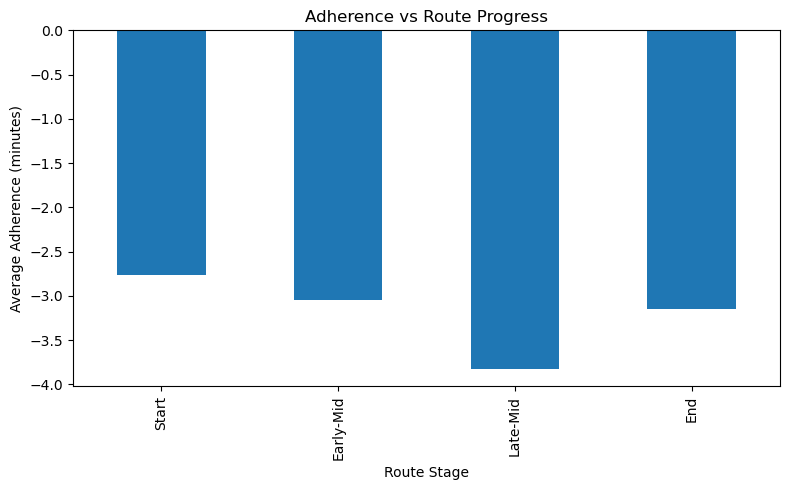

In [29]:
import matplotlib.pyplot as plt

stage_perf.plot(kind='bar', figsize=(8,5))

plt.title('Adherence vs Route Progress')
plt.xlabel('Route Stage')
plt.ylabel('Average Adherence (minutes)')
plt.tight_layout()
plt.show()

On-time performance does not consistently become less stable as the bus travels further along the route. Although there are small fluctuations in adherence, there is no clear pattern of worsening performance toward the end of the trip.

9. Headway is the amount of time between a bus and the prior bus at the same stop. In the dataset, the amount of headway scheduled is contained in the SCHEDULED_HDWY column and indicates the difference between the scheduled time for a particular stop and the scheduled time for the previous bus on that same stop. This dataset contains a column HDWY_DEV, which shows the amount of deviation from the scheduled headway. Bunching occurs when there is shorter headway than scheduled, which would appear as a negative HDWY_DEV value. Gapping is when there is more headway than scheduled and appears as a positive value in the HDWY_DEV column. Note that you can calculate headway deviation percentage as HDWY_DEV/SCHEDULED_HDWY. The generally accepted range of headway deviation is 50% to 150% of the scheduled headway, so if scheduled headway is 10 minutes, a headway deviation of up to 5 minutes would be acceptable (but not ideal). How do the variables studied related to headway deviation?

In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv('Headway Data, 8-1-2023 to 9-30-2023.csv')

df['HDWY_DEV'] = pd.to_numeric(df['HDWY_DEV'], errors='coerce')
df['SCHEDULED_HDWY'] = pd.to_numeric(df['SCHEDULED_HDWY'], errors='coerce')

# remove invalid values
df = df[df['SCHEDULED_HDWY'] > 0]

df['hdwy_dev_pct'] = df['HDWY_DEV'] / df['SCHEDULED_HDWY']

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['hdwy_dev_pct'])

In [31]:
df['ACTUAL_ARRIVAL_TIME'] = pd.to_datetime(df['ACTUAL_ARRIVAL_TIME'], errors='coerce')
df['hour'] = df['ACTUAL_ARRIVAL_TIME'].dt.hour

time_effect = df.groupby(pd.cut(df['hour'], bins=[0,6,9,15,19,24]))['hdwy_dev_pct'].mean()

print(time_effect)

hour
(0, 6]      0.025307
(6, 9]      0.027517
(9, 15]     0.033820
(15, 19]    0.036496
(19, 24]    0.027451
Name: hdwy_dev_pct, dtype: float64


C:\Users\Student\AppData\Local\Temp\ipykernel_8212\2059872773.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_effect = df.groupby(pd.cut(df['hour'], bins=[0,6,9,15,19,24]))['hdwy_dev_pct'].mean()


In [32]:
df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
df['day_of_week'] = df['DATE'].dt.day_name()

dow_effect = df.groupby('day_of_week')['hdwy_dev_pct'].mean()

print(dow_effect)

day_of_week
Friday       0.043354
Monday       0.022386
Saturday     0.022888
Sunday       0.036655
Thursday     0.037569
Tuesday      0.028291
Wednesday    0.028413
Name: hdwy_dev_pct, dtype: float64


In [33]:
op_effect = df.groupby('OPERATOR')['hdwy_dev_pct'].mean().sort_values()

print(op_effect.head())
print(op_effect.tail())

OPERATOR
656    -1.000000
2338   -0.395035
2256   -0.285000
1606   -0.231865
3127   -0.229792
Name: hdwy_dev_pct, dtype: float64
OPERATOR
3165    0.462789
2752    0.489852
3015    0.587170
3128    0.622328
2309    0.685068
Name: hdwy_dev_pct, dtype: float64


In [34]:
df['ACTUAL_DEPARTURE_TIME'] = pd.to_datetime(df['ACTUAL_DEPARTURE_TIME'], errors='coerce')
df['ACTUAL_ARRIVAL_TIME'] = pd.to_datetime(df['ACTUAL_ARRIVAL_TIME'], errors='coerce')

df['layover'] = (df['ACTUAL_DEPARTURE_TIME'] - df['ACTUAL_ARRIVAL_TIME']).dt.total_seconds()/60

layover_corr = df['layover'].corr(df['hdwy_dev_pct'])

print("Layover vs Headway deviation:", layover_corr)

Layover vs Headway deviation: -0.00018691268684436162


In [35]:
df['ROUTE_STOP_SEQUENCE'] = pd.to_numeric(df['ROUTE_STOP_SEQUENCE'], errors='coerce')

route_corr = df['ROUTE_STOP_SEQUENCE'].corr(df['hdwy_dev_pct'])

print("Route position vs Headway deviation:", route_corr)

Route position vs Headway deviation: -0.015096351888839817


Headway deviation is influenced by several operational factors, but none show extremely strong relationships. Time of day, day of week, operator, layover time, and route position all show only weak relationships with headway deviation. This suggests that bus spacing reliability is not driven by a single factor, but instead from a combination of operational conditions such as traffic, scheduling, and route complexity.

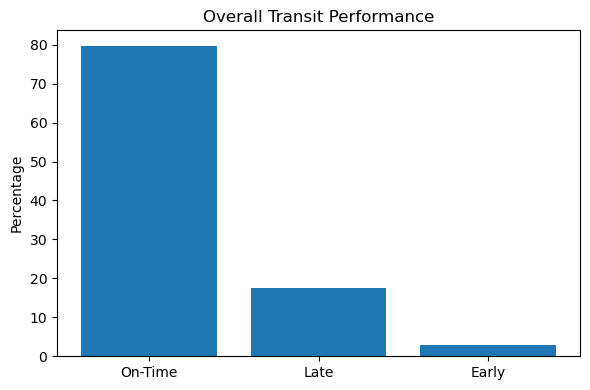

In [36]:
import matplotlib.pyplot as plt

labels = ['On-Time', 'Late', 'Early']
values = [ontime_pct, late_pct, early_pct]  # from your earlier code

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title("Overall Transit Performance")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

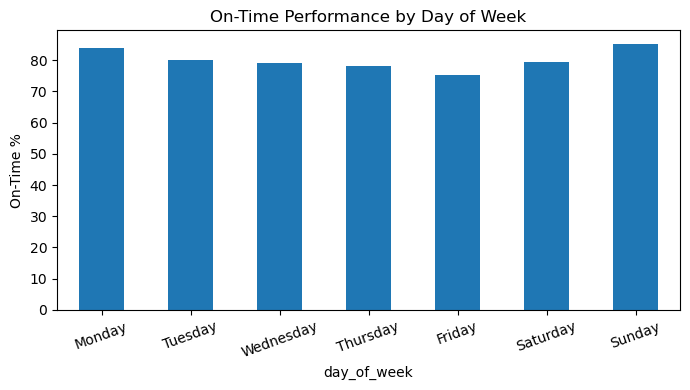

In [38]:
dow_perf['on_time_pct'].reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]).plot(kind='bar', figsize=(7,4))

plt.title("On-Time Performance by Day of Week")
plt.ylabel("On-Time %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

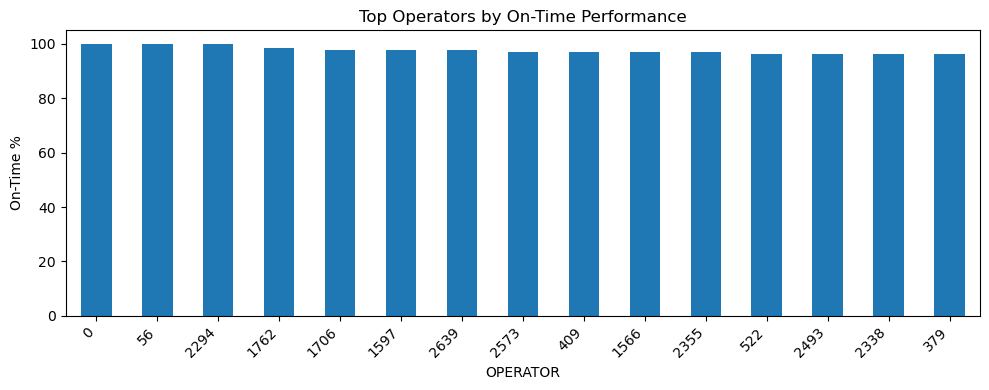

In [39]:
operator_perf['on_time_pct'].head(15).plot(kind='bar', figsize=(10,4))

plt.title("Top Operators by On-Time Performance")
plt.ylabel("On-Time %")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()